In [6]:
!pip install -U langchain-huggingface langchain-community langchain-groq faiss-cpu sentence-transformers sklearn-pandas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.feature_extraction.text import TfidfVectorizer

from sentence_transformers import SentenceTransformer

import tensorflow as tf
from tensorflow.keras import layers, models


from langchain_community.vectorstores import FAISS as LC_FAISS

from langchain_core.prompts import PromptTemplate

from langchain_community.embeddings import HuggingFaceEmbeddings
from langchain_core.prompts import PromptTemplate


import os
from langchain_groq import ChatGroq
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser
from langchain_core.runnables import RunnablePassthrough
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_community.vectorstores import SKLearnVectorStore
from langchain_core.documents import Document


In [7]:
df = pd.read_csv("/kaggle/input/datasets/arshkon/linkedin-job-postings/postings.csv")
df.head()

,job_id,company_name,title,description,max_salary,pay_period,location,company_id,views,med_salary,...,skills_desc,listed_time,posting_domain,sponsored,work_type,currency,compensation_type,normalized_salary,zip_code,fips
0,921716,Corcoran Sawyer Smith,Marketing Coordinator,Job descriptionA leading real estate firm in N...,20.0,HOURLY,"Princeton, NJ",2774458.0,20.0,NaN,...,Requirements: \n\nWe are seeking a College or ...,1.713398e+12,NaN,0,FULL_TIME,USD,BASE_SALARY,38480.0,8540.0,34021.0
1,1829192,NaN,Mental Health Therapist/Counselor,"At Aspen Therapy and Wellness , we are committ...",50.0,HOURLY,"Fort Collins, CO",NaN,1.0,NaN,...,NaN,1.712858e+12,NaN,0,FULL_TIME,USD,BASE_SALARY,83200.0,80521.0,8069.0
2,10998357,The National Exemplar,Assitant Restaurant Manager,The National Exemplar is accepting application...,65000.0,YEARLY,"Cincinnati, OH",64896719.0,8.0,NaN,...,We are currently accepting resumes for FOH - A...,1.713278e+12,NaN,0,FULL_TIME,USD,BASE_SALARY,55000.0,45202.0,39061.0
3,23221523,"Abrams Fensterman, LLP",Senior Elder Law / Trusts and Estates Associat...,Senior Associate Attorney - Elder Law / Trusts...,175000.0,YEARLY,"New Hyde Park, NY",766262.0,16.0,NaN,...,This position requires a baseline understandin...,1.712896e+12,NaN,0,FULL_TIME,USD,BASE_SALARY,157500.0,11040.0,36059.0
4,35982263,NaN,Service Technician,Looking for HVAC service tech with experience ...,80000.0,YEARLY,"Burlington, IA",NaN,3.0,NaN,...,NaN,1.713452e+12,NaN,0,FULL_TIME,USD,BASE_SALARY,70000.0,52601.0,19057.0


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 123849 entries, 0 to 123848
Data columns (total 31 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   job_id                      123849 non-null  int64  
 1   company_name                122130 non-null  object 
 2   title                       123849 non-null  object 
 3   description                 123842 non-null  object 
 4   max_salary                  29793 non-null   float64
 5   pay_period                  36073 non-null   object 
 6   location                    123849 non-null  object 
 7   company_id                  122132 non-null  float64
 8   views                       122160 non-null  float64
 9   med_salary                  6280 non-null    float64
 10  min_salary                  29793 non-null   float64
 11  formatted_work_type         123849 non-null  object 
 12  applies                     23320 non-null   float64
 13  original_liste

In [9]:
df.describe()

,job_id,max_salary,company_id,views,med_salary,min_salary,applies,original_listed_time,remote_allowed,expiry,closed_time,listed_time,sponsored,normalized_salary,zip_code,fips
count,1.238490e+05,2.979300e+04,1.221320e+05,122160.000000,6280.000000,2.979300e+04,23320.000000,1.238490e+05,15246.0,1.238490e+05,1.073000e+03,1.238490e+05,123849.0,3.607300e+04,102977.000000,96434.000000
mean,3.896402e+09,9.193942e+04,1.220401e+07,14.618247,22015.619876,6.491085e+04,10.591981,1.713152e+12,1.0,1.716213e+12,1.712928e+12,1.713204e+12,0.0,2.053270e+05,50400.491887,28713.879887
std,8.404355e+07,7.011101e+05,2.554143e+07,85.903598,52255.873846,4.959738e+05,29.047395,4.848209e+08,0.0,2.321394e+09,3.622893e+08,3.989122e+08,0.0,5.097627e+06,30252.232515,16015.929825
min,9.217160e+05,1.000000e+00,1.009000e+03,1.000000,0.000000,1.000000e+00,1.000000,1.701811e+12,1.0,1.712903e+12,1.712346e+12,1.711317e+12,0.0,0.000000e+00,1001.000000,1003.000000
25%,3.894587e+09,4.828000e+01,1.435200e+04,3.000000,18.940000,3.700000e+01,1.000000,1.712863e+12,1.0,1.715481e+12,1.712670e+12,1.712886e+12,0.0,5.200000e+04,24112.000000,13121.000000
50%,3.901998e+09,8.000000e+04,2.269650e+05,4.000000,25.500000,6.000000e+04,3.000000,1.713395e+12,1.0,1.716042e+12,1.712670e+12,1.713408e+12,0.0,8.150000e+04,48059.000000,29183.000000
75%,3.904707e+09,1.400000e+05,8.047188e+06,8.000000,2510.500000,1.000000e+05,8.000000,1.713478e+12,1.0,1.716088e+12,1.713283e+12,1.713484e+12,0.0,1.250000e+05,78201.000000,42077.000000
max,3.906267e+09,1.200000e+08,1.034730e+08,9975.000000,750000.000000,8.500000e+07,967.000000,1.713573e+12,1.0,1.729125e+12,1.713562e+12,1.713573e+12,0.0,5.356000e+08,99901.000000,56045.000000


In [10]:
df = df.dropna(subset=['description'])

In [11]:
df_ml = df.dropna(subset=['normalized_salary']).copy()

In [12]:
df_ml['formatted_experience_level'] = df_ml['formatted_experience_level'].fillna('Not Specified')

In [13]:
df_ml['applies'] = df_ml['applies'].fillna(0)

In [14]:
print(f"Original size: {len(df)}")
print(f"Size after cleaning for ML: {len(df_ml)}")

Original size: 123842
Size after cleaning for ML: 36072


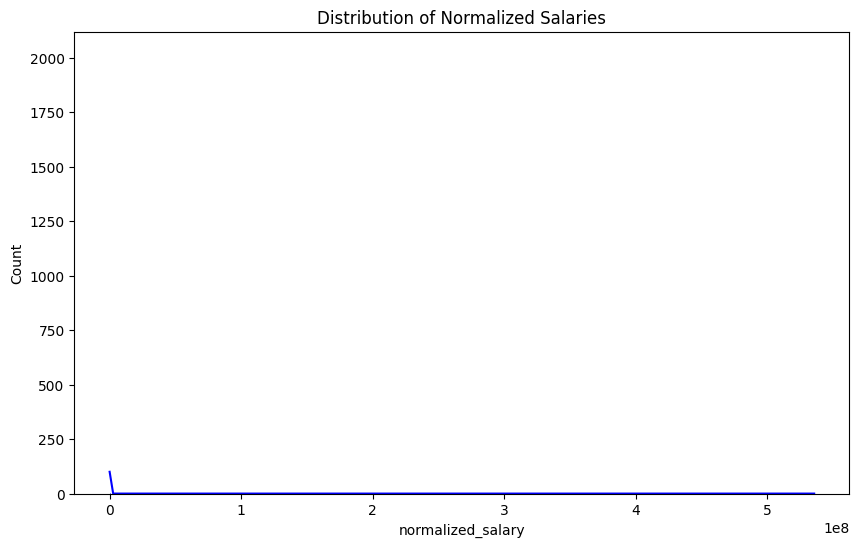

In [15]:
# Salary Distribution
# Check the range and frequency of salaries
plt.figure(figsize=(10, 6))
sns.histplot(df_ml['normalized_salary'], kde=True, color='blue')
plt.title('Distribution of Normalized Salaries')
plt.show()

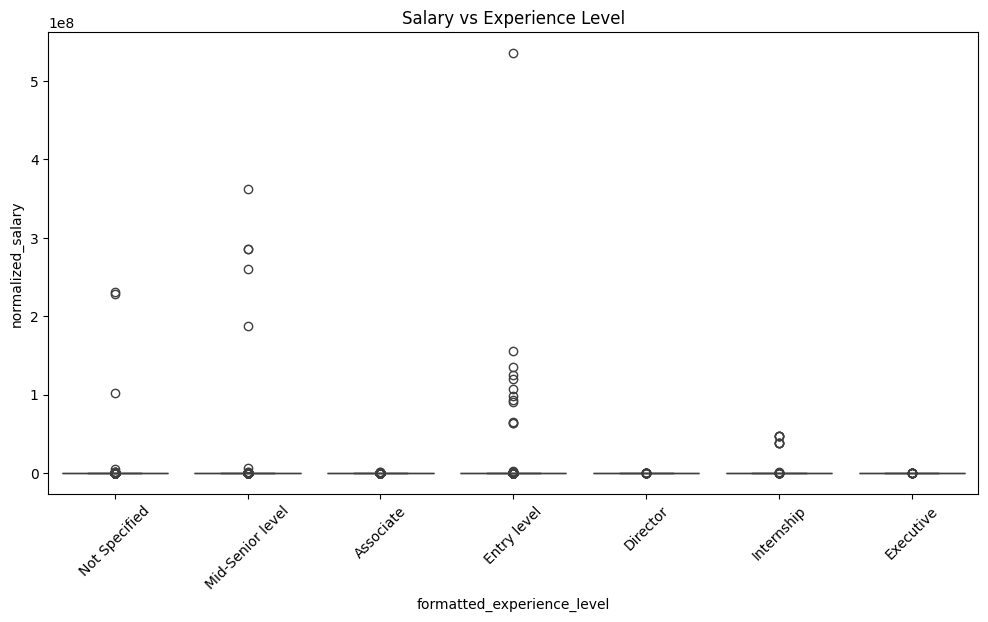

In [16]:
#  Salary vs Experience Level
# See how experience level impacts pay
plt.figure(figsize=(12, 6))
sns.boxplot(x='formatted_experience_level', y='normalized_salary', data=df_ml)
plt.xticks(rotation=45)
plt.title('Salary vs Experience Level')
plt.show()

In [17]:
#  Filter outliers using percentiles (removing top and bottom 1%)
lower_limit = df_ml['normalized_salary'].quantile(0.01)
upper_limit = df_ml['normalized_salary'].quantile(0.99)

df_ml_clean = df_ml[(df_ml['normalized_salary'] > lower_limit) & 
                    (df_ml['normalized_salary'] < upper_limit)].copy()

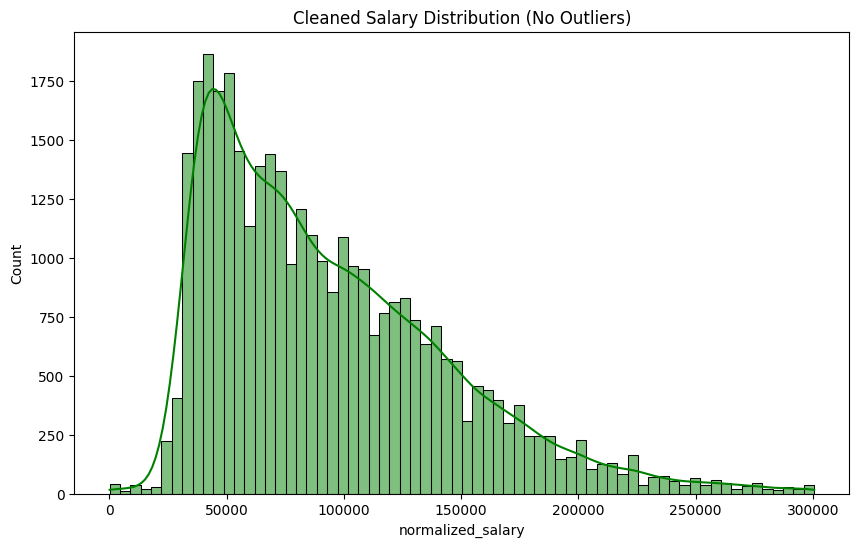

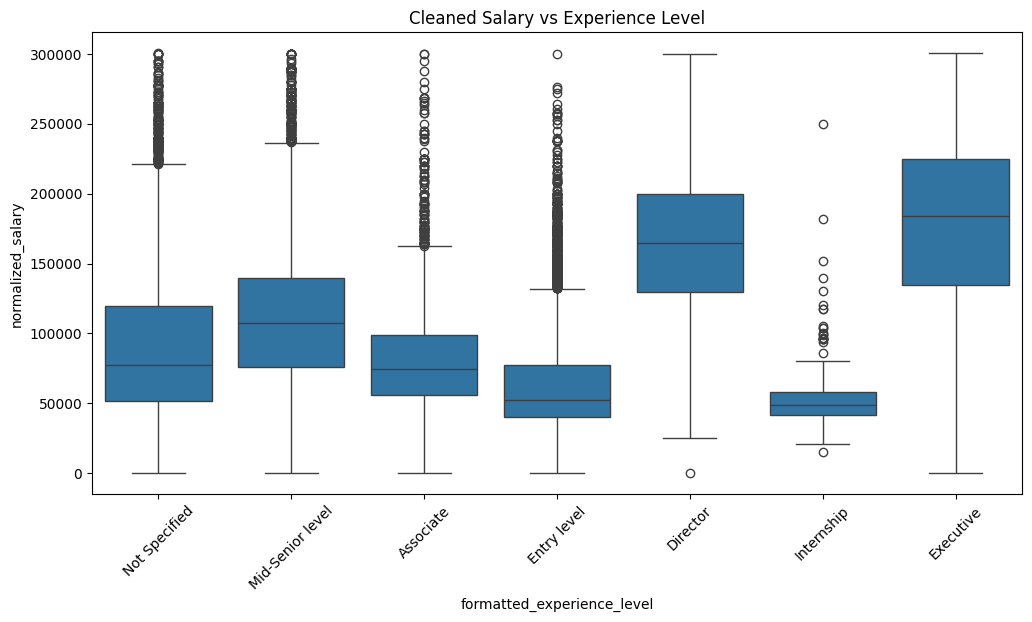

In [18]:
# Re-plot the distribution to see the difference
plt.figure(figsize=(10, 6))
sns.histplot(df_ml_clean['normalized_salary'], kde=True, color='green')
plt.title('Cleaned Salary Distribution (No Outliers)')
plt.show()

#. Re-plot Salary vs Experience
plt.figure(figsize=(12, 6))
sns.boxplot(x='formatted_experience_level', y='normalized_salary', data=df_ml_clean)
plt.xticks(rotation=45)
plt.title('Cleaned Salary vs Experience Level')
plt.show()

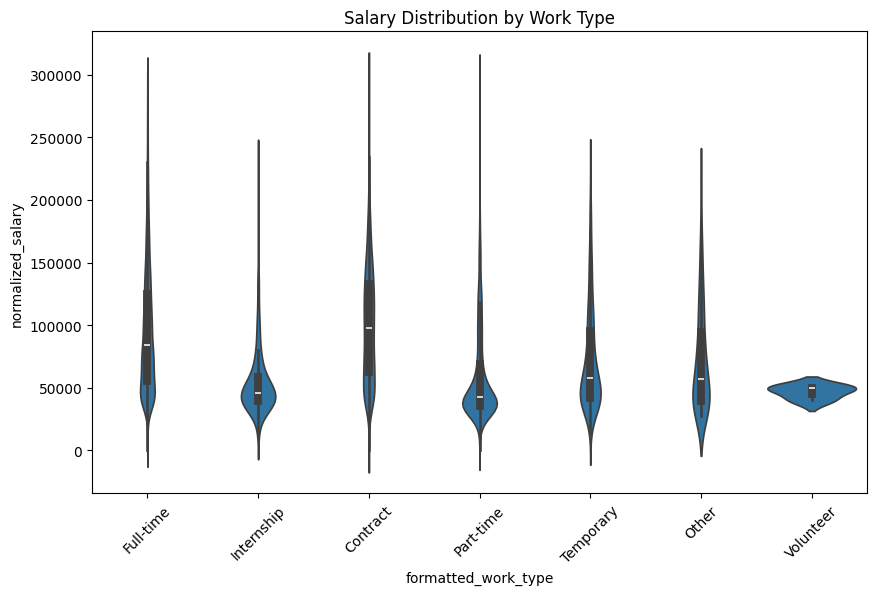

In [19]:
# Salary distribution by Work Type
plt.figure(figsize=(10, 6))
sns.violinplot(x='formatted_work_type', y='normalized_salary', data=df_ml_clean)
plt.title('Salary Distribution by Work Type')
plt.xticks(rotation=45)
plt.show()

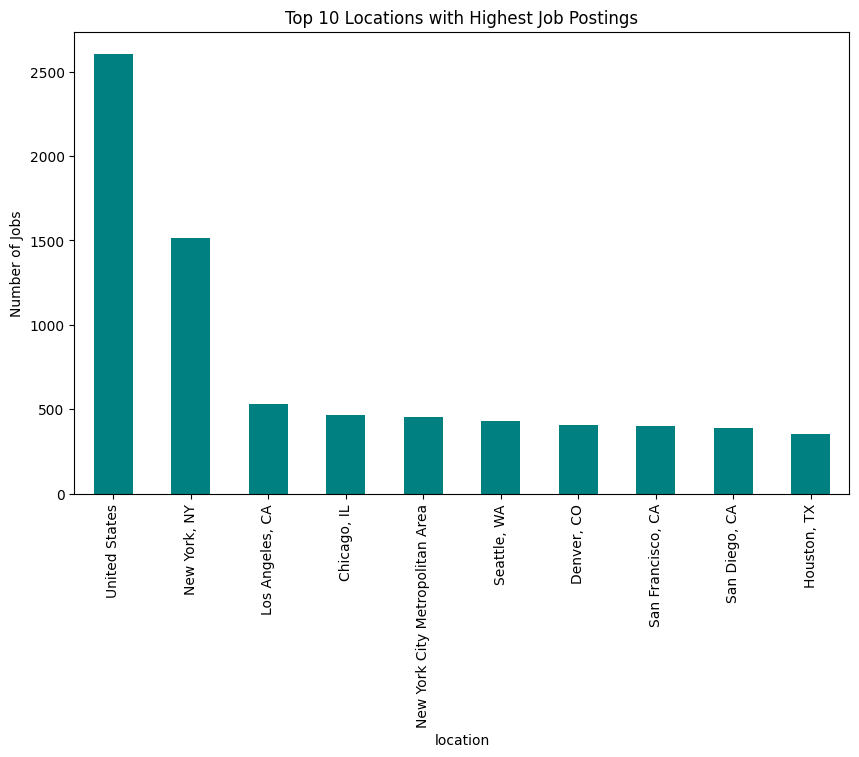

In [20]:
#  Top 10 Locations by job postings
plt.figure(figsize=(10, 6))
df_ml['location'].value_counts().nlargest(10).plot(kind='bar', color='teal')
plt.title('Top 10 Locations with Highest Job Postings')
plt.ylabel('Number of Jobs')
plt.show()

In [21]:
#Feature Selection
selected_features = ['location', 'formatted_experience_level', 'formatted_work_type', 'applies']
X = df_ml_clean[selected_features].copy()
y= df_ml_clean['normalized_salary']

In [22]:
#  Categorical Encoding
le = LabelEncoder()
for col in ['location', 'formatted_experience_level', 'formatted_work_type']:
    X[col] = le.fit_transform(X[col].astype(str))

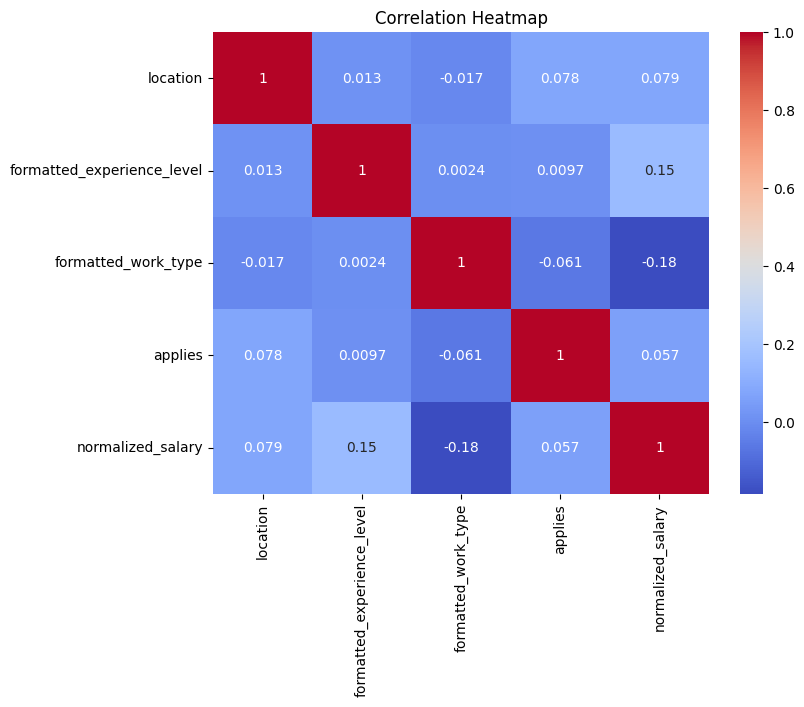

In [23]:
#  Correlation Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(X.join(y).corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

In [24]:
#  Data Splitting
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Features shape: {X_train.shape}")

Features shape: (28278, 4)


In [25]:
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [26]:
y_pred = model.predict(X_test)

In [27]:
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error: {mae:.2f}")
print(f"R2 Score: {r2:.2f}")

Mean Absolute Error: 32881.65
R2 Score: 0.23


In [28]:
#  Load the Transformer model (Deep Learning Part)
# This model captures semantic meaning better than TF-IDF
model_st = SentenceTransformer('all-MiniLM-L6-v2')

documents = df_ml_clean['description'].astype(str).tolist()

# 3. Generate Embeddings using Batches to save memory
embeddings = model_st.encode(documents, batch_size=32, show_progress_bar=True)

print(f"Successfully generated {embeddings.shape[0]} embeddings!")

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/1105 [00:00<?, ?it/s]

Successfully generated 35348 embeddings!


In [30]:
# We use the embeddings as X and normalized_salary as y
X_dl = embeddings
y_dl = df_ml_clean['normalized_salary'].values

X_train_dl, X_test_dl, y_train_dl, y_test_dl = train_test_split(X_dl, y_dl, test_size=0.2, random_state=42)

# 2. Build the Deep Learning Model (MLP)
# This captures complex patterns in the job descriptions
model_dl = models.Sequential([
    layers.Dense(512, activation='relu', input_shape=(X_train_dl.shape[1],)),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(128, activation='relu'),
    layers.Dense(1, activation='linear') # Output: Predicted Salary
])

#  Compile the model
model_dl.compile(optimizer='adam', loss='mse', metrics=['mae'])

# 4. Train the model 
history = model_dl.fit(
    X_train_dl, y_train_dl,
    validation_split=0.2,
    epochs=50,            
    batch_size=64,        
    verbose=1
)

Epoch 1/50
354/354 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - loss: 7824338432.0000 - mae: 71429.7969 - val_loss: 1975377408.0000 - val_mae: 33753.4023
Epoch 2/50
354/354 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 1877106432.0000 - mae: 32663.5742 - val_loss: 1713089920.0000 - val_mae: 30917.5723
Epoch 3/50
354/354 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 1688510080.0000 - mae: 30491.9082 - val_loss: 1627573632.0000 - val_mae: 30169.3359
Epoch 4/50
354/354 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 1597248128.0000 - mae: 29672.7500 - val_loss: 1578954624.0000 - val_mae: 29393.7793
Epoch 5/50
354/354 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 1571790208.0000 - mae: 29166.1152 - val_loss: 1550366336.0000 - val_mae: 29085.2500
Epoch 6/50
354/354 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 1517577856.0000 - mae: 28731.3398 - val_loss: 1527704064.0000 - val_mae: 28411.1113
Epoch 7/50
354/354 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 1504986112.0000 - mae: 28476.8828 - val_loss: 1513807104.0000 - val_mae: 285

221/221 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


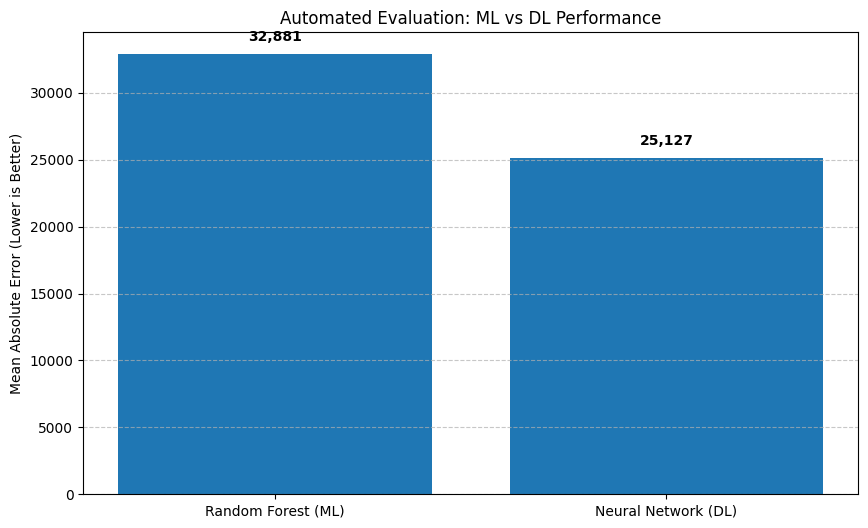

Random Forest MAE: 32,881
Deep Learning MAE: 25,127


In [34]:
from sklearn.metrics import mean_absolute_error
import matplotlib.pyplot as plt
import numpy as np

# 1. Calculate MAE for Random Forest (ML)
rf_predictions = model.predict(X_test)
rf_mae = mean_absolute_error(y_test, rf_predictions)

# 2. Calculate MAE for Neural Network (DL)
dl_predictions = model_dl.predict(X_test_dl).flatten()
dl_mae = mean_absolute_error(y_test_dl, dl_predictions)

# 3. Dynamic Plotting
models = ['Random Forest (ML)', 'Neural Network (DL)']
mae_values = [rf_mae, dl_mae]

plt.figure(figsize=(10, 6))
bars = plt.bar(models, mae_values)

plt.ylabel('Mean Absolute Error (Lower is Better)')
plt.title('Automated Evaluation: ML vs DL Performance')


for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 1000, f'{int(yval):,}', ha='center', fontweight='bold')

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

print(f"Random Forest MAE: {int(rf_mae):,}")
print(f"Deep Learning MAE: {int(dl_mae):,}")

In [35]:
import joblib

joblib.dump(model_dl, "salary_model.pkl")

['salary_model.pkl']

In [36]:
# 1. Install FAISS
!pip install faiss-cpu -q

import faiss

# 2. Initialize the FAISS index
# We use IndexFlatL2 for exact L2 distance search (great for embeddings)
dimension = embeddings.shape[1] # This will be 384
index = faiss.IndexFlatL2(dimension)

# 3. Add our deep learning embeddings to the index
# FAISS requires float32 format
index.add(embeddings.astype('float32'))
faiss.write_index(index, "jobs_index.faiss")
# 4. Create the Search Function
def search_jobs_faiss(query, n_results=3):
    # Convert query to embedding using our pre-trained model
    query_embedding = model_st.encode([query]).astype('float32')
    
    # Search the index
    distances, indices = index.search(query_embedding, n_results)
    
    # Get the results from our dataframe
    results = df_ml_clean.iloc[indices[0]]
    return results

# Test the Semantic Search
print("Searching for: 'AI and Machine Learning Engineer'...")
top_jobs = search_jobs_faiss("AI and Machine Learning Engineer")
print(top_jobs[['title', 'company_name', 'location']])

Searching for: 'AI and Machine Learning Engineer'...
                                     title              company_name  \
31203       Generative AI Engineer, Senior       Booz Allen Hamilton   
84018            Machine Learning Engineer                     eTeam   
100458  Machine Learning Engineer - Remote  Orbit Recruitment Group    

                      location  
31203               McLean, VA  
84018             San Jose, CA  
100458  Los Angeles County, CA  


In [ ]:
# 1. Install & Import Groq
!pip install groq -q
from groq import Groq

# 2. Setup Client 
client_groq = Groq(api_key="GROQ_API_KEY")

# 3. The Final RAG Function
def ask_ai_about_jobs(user_query):
    # Step A: Retrieve 3 matching jobs from FAISS index
    context_jobs = search_jobs_faiss(user_query, n_results=3)
    
    # Step B: Format the retrieved data into a string
    context_text = ""
    for idx, row in context_jobs.iterrows():
        context_text += f"- Title: {row['title']} at {row['company_name']} in {row['location']}\n"
    
    # Step C: Send the context and query to Llama 3.1
    prompt = f"""
    You are a professional career advisor for the 'OFOQ' system. 
    Based on the following job listings from our database, answer the user's question: '{user_query}'
    
    Database Listings:
    {context_text}
    
    Summary:
    """
    
    chat_completion = client_groq.chat.completions.create(
        messages=[{"role": "user", "content": prompt}],
        model="llama-3.1-8b-instant", 
    )
    
    return chat_completion.choices[0].message.content



In [38]:
# Test the System!
print("--- AI Assistant Response ---")
print(ask_ai_about_jobs("Find me some interesting Machine Learning roles"))

--- AI Assistant Response ---
Based on the job listings in your OFOQ database, I've identified some interesting Machine Learning roles for you:

1. **Lead Machine Learning Engineer at Confidential Jobs in United States**: This role appears to be a senior-level position, requiring experience in leading machine learning engineering teams and expertise in developing predictive models. It would be an excellent opportunity to work on complex projects and manage a team of engineers.

2. **Sr. Staff Data Scientist at Blue Yonder in Dallas, TX**: This role seems to focus on data science and machine learning expertise, particularly in a retail or supply chain context. As a senior staff data scientist, you would be responsible for developing data-driven solutions and contributing to the company's data science strategy.

3. **AI/ML Engineering Manager at SEPHORA in San Francisco Bay Area**: This role is focused on managing a team of AI and machine learning engineers. As an engineering manager, yo

In [39]:
companies = pd.read_csv("/kaggle/input/datasets/arshkon/linkedin-job-postings/companies/companies.csv")
job_skills = pd.read_csv("/kaggle/input/datasets/arshkon/linkedin-job-postings/jobs/job_skills.csv")
skills_map = pd.read_csv("/kaggle/input/datasets/arshkon/linkedin-job-postings/mappings/skills.csv")

In [40]:

job_skills = job_skills.merge(skills_map, on="skill_abr", how="left")

skills_grouped = job_skills.groupby("job_id")["skill_name"].apply(lambda x: ", ".join(x.astype(str))).reset_index()

print(skills_grouped.head())

     job_id                                    skill_name
0    921716                              Marketing, Sales
1   1218575                          Health Care Provider
2   1829192                          Health Care Provider
3   2264355  Design, Art/Creative, Information Technology
4  10998357                     Management, Manufacturing


In [41]:
df_full = df_ml_clean.merge(skills_grouped, left_on="job_id", right_on="job_id", how="left")
df_full = df_full.merge(companies, on="company_id", how="left")

# Fill missing
df_full["skill_name"] = df_full["skill_name"].fillna("Not Specified")
df_full["name"] = df_full["name"].fillna("Unknown Company")

In [42]:
documents = []

for _, row in df_full.iterrows():
    text = f"""
    Job Title: {row.get('title', '')}
    Company: {row.get('name', '')}
    Location: {row.get('location', '')}
    Experience: {row.get('formatted_experience_level', '')}
    Work Type: {row.get('formatted_work_type', '')}
    Skills: {row.get('skill_name', '')}
    Applies: {row.get('applies', 0)}
    Salary: {row.get('normalized_salary', 'Unknown')}
    
    Description:
    {row.get('description', '')}
    """
    
    documents.append(Document(page_content=text))
    
print(f"Created {len(documents)} rich documents!")

Created 35348 rich documents!


In [43]:
embedding_model = HuggingFaceEmbeddings(model_name="sentence-transformers/all-MiniLM-L6-v2")

vector_db = LC_FAISS.from_documents(documents, embedding_model)
retriever = vector_db.as_retriever(search_kwargs={"k": 3})

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [44]:
def ask_langchain_ai(query):
    
    docs = retriever.invoke(query)
    
    context = "\n\n".join([doc.page_content for doc in docs])
    
    prompt = f"""
    You are a professional career advisor.
    
    Based on the following job data:
    {context}
    
    Answer this question:
    {query}
    """
    
    response = client_groq.chat.completions.create(
        messages=[{"role": "user", "content": prompt}],
        model="llama-3.1-8b-instant"
    )
    
    return response.choices[0].message.content


In [45]:
print(ask_langchain_ai("Find me high paying Machine Learning jobs with Python"))

Based on the job data provided, I've compiled a list of high-paying Machine Learning jobs with Python that might be of interest to you. Please note that the salary ranges are estimates and may vary based on factors like location, experience, and company.

**Job Title: Senior Python Machine Learning Engineer**

* Company: Accenture
* Location: Raleigh, NC (or remote)
* Experience: Mid-Senior level (4-8 years)
* Work Type: Full-time
* Salary: $143,800 - $200,000 per year
* Description: Design and develop complex machine learning models using Python to drive business decisions.

**Job Title: Natural Language Processing (NLP) Engineer**

* Company: Palantir
* Location: Chicago, IL (or remote)
* Experience: Mid-Senior level (4-8 years)
* Work Type: Full-time
* Salary: $155,000 - $220,000 per year
* Description: Develop and deploy NLP algorithms using Python to extract insights from unstructured data.

**Job Title: Data Scientist (Machine Learning)**

* Company: IBM
* Location: New York, NY 

In [46]:
!pip install gradio

In [47]:
import gradio as gr

def career_advisor_ui(query):
    """
    Wrapper function to handle the UI logic and error catching.
    """
    if not query.strip():
        return "Please enter a valid career-related question."
    
    try:
        # Calling your existing LangChain function
        response = ask_langchain_ai(query)
        return response
    except Exception as e:
        return f"⚠️ Error: {str(e)}\n\nEnsure your Groq API key is set and the retriever is initialized."

# Define the Gradio Interface
demo = gr.Interface(
    fn=career_advisor_ui,
    inputs=gr.Textbox(
        lines=3, 
        placeholder="e.g., What are the top skills for Machine Learning jobs with a salary over $100k?",
        label="Ask your Career Advisor"
    ),
    outputs=gr.Markdown(label="Advisor Response"),
    title="🤖 AI-Powered Career Advisor",
    description="Ask questions about LinkedIn job postings, required skills, and salary trends.",
    theme="soft",
    examples=[
        ["Find me high paying Machine Learning jobs with Python"],
        ["What are the most common skills for Data Scientists?"],
        ["List jobs that mention 'Remote' work."]
    ]
)

demo.launch(share=True)

* Running on local URL:  http://127.0.0.1:7860
* Running on public URL: https://3ae65e2f73999fa2ab.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
